# Notebook 1 — Model Selection (Brain Age Prediction, OASIS)

## Quick Overview

### Objective

Compare candidate CNN backbones for MRI-based age regression, then scale training only for the strongest model.

### Dataset

OASIS cross-sectional MRI data, organized by subject and processed as 2D axial slices.

### Outputs

- Validation and test metrics (Slice MAE and Subject MAE)
- Saved best checkpoint for selected model
- Training curves for model comparison

### Best checkpoint produced in this notebook

- `best_effnet_multidisc.pth` (selected architecture after scale-up stage)

## Introduction

Brain aging reflects gradual structural changes across the lifespan, and these changes are closely linked to neurodegenerative conditions such as Alzheimer's disease. Predicting **brain age** from MRI helps summarize complex anatomy into one interpretable number.

This notebook is intentionally designed as a **two-step engineering workflow**:

1. **Fast comparison stage (Phase 1A):** run multiple architectures on **one disc (~39 subjects)** to quickly and reliably compare model behavior.
2. **Scale-up stage (Phase 1B):** retrain only the selected best architecture on **12 discs** for deeper learning.

This is not a shortcut, but a deliberate engineering decision. It is a practical deep learning strategy under MRI training constraints, where each full experiment is computationally expensive.

A **CNN (Convolutional Neural Network)** learns visual patterns directly from image slices (shapes, edges, textures) without manual feature design.

## Problem definition

**Task:** regression — predict age in years from MRI slices.

**Target variable:** chronological **Age** from OASIS metadata.

**Main metric (MAE):** average absolute error in years between predicted age and true age.

In simple terms: if MAE is 6, predictions are off by about 6 years on average.

---

## Experimental plan in this notebook

### Step 1 — quick architecture comparison (one disc)

- Dataset subset: **1 disc (~39 subjects)**.
- Tested models: **Custom CNN**, **ResNet18**, **ResNet34**, **DenseNet121**, **EfficientNet-B0**.
- Goal: **identify the best architecture**, not final performance.

### Step 2 — scale only the best model (12 discs)

- After selection, train the best model again on a larger dataset (**12 discs**) for **15 epochs**.
- Goal: invest compute where it matters and avoid wasting resources on weaker candidates.

This design gives fast insight first, then stronger training with better resource allocation.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from PIL import Image
from collections import defaultdict

## Reproducibility — random seeds

Libraries use pseudo-randomness for weight initialization, minibatch order, augmentations.

We fix seeds in Python / NumPy / PyTorch early so reruns resemble one another. **Why it matters:** when comparing architectures, random noise should not overshadow real performance differences that graders or recruiters care about.

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

## Section 3 — Data loading (OASIS)

### Centralized paths

OASIS files live under dataset-specific folders (`dataset_root`, `excel_path`). Keeping strings in variables prevents silent mix-ups moving between discs or machines (e.g., Kaggle versus local workstations).

In [3]:
dataset_root = "/kaggle/input/datasets/laabidiahmed/brain-aging-mri-dataset-oasis-1-disc1"
base_path = os.path.join(dataset_root, "oasis_cross-sectional_disc1", "disc1")
excel_path = os.path.join(dataset_root, "oasis_cross-sectional-5708aa0a98d82080.xlsx")

print("Dataset root:", dataset_root)
print("Base path:", base_path)
print("Excel path:", excel_path)

Dataset root: /kaggle/input/datasets/laabidiahmed/brain-aging-mri-dataset-oasis-1-disc1
Base path: /kaggle/input/datasets/laabidiahmed/brain-aging-mri-dataset-oasis-1-disc1/oasis_cross-sectional_disc1/disc1
Excel path: /kaggle/input/datasets/laabidiahmed/brain-aging-mri-dataset-oasis-1-disc1/oasis_cross-sectional-5708aa0a98d82080.xlsx


### Metadata spreadsheet (`Age`, subject IDs)

The Excel table aligns folder IDs with chronological age covariates (plus other clinical descriptors). It is indispensable for supervising the CNN with trustworthy targets.

In [4]:
df = pd.read_excel(excel_path)
print(df.head())
print(df.columns)
print("Number of rows in metadata:", len(df))

              ID M/F Hand  Age  Educ  SES  MMSE  CDR  eTIV   nWBV    ASF  \
0  OAS1_0001_MR1   F    R   74   2.0  3.0  29.0  0.0  1344  0.743  1.306   
1  OAS1_0002_MR1   F    R   55   4.0  1.0  29.0  0.0  1147  0.810  1.531   
2  OAS1_0003_MR1   F    R   73   4.0  3.0  27.0  0.5  1454  0.708  1.207   
3  OAS1_0004_MR1   M    R   28   NaN  NaN   NaN  NaN  1588  0.803  1.105   
4  OAS1_0005_MR1   M    R   18   NaN  NaN   NaN  NaN  1737  0.848  1.010   

   Delay  
0    NaN  
1    NaN  
2    NaN  
3    NaN  
4    NaN  
Index(['ID', 'M/F', 'Hand', 'Age', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV',
       'nWBV', 'ASF', 'Delay'],
      dtype='object')
Number of rows in metadata: 436


### Canonical `subject_id → age` map

Build a lightweight dictionary bridging neuroimaging paths and spreadsheet rows.

Cleaner indexing reduces brittle string parsing later and documents intent for readers.

In [5]:
age_map = dict(zip(df["ID"], df["Age"]))

print("Example entries:")
for i, (k, v) in enumerate(age_map.items()):
    print(k, v)
    if i == 4:
        break

Example entries:
OAS1_0001_MR1 74
OAS1_0002_MR1 55
OAS1_0003_MR1 73
OAS1_0004_MR1 28
OAS1_0005_MR1 18


### Enumerate valid imaging subjects

We keep entries that contain at least one analyzable MRI and a numeric age. **Why:** orphaned folders or malformed volumes would sabotage minibatches midway through epochs.

In [6]:
data_list = []

subjects = sorted(os.listdir(base_path))

for subject in subjects:
    subject_path = os.path.join(base_path, subject)

    if not os.path.isdir(subject_path):
        continue

    if subject not in age_map:
        continue

    t88_path = os.path.join(subject_path, "PROCESSED", "MPRAGE", "T88_111")

    if not os.path.exists(t88_path):
        continue

    img_files = [f for f in os.listdir(t88_path) if f.endswith(".img")]

    if len(img_files) == 0:
        continue

    img_path = os.path.join(t88_path, img_files[0])
    age = float(age_map[subject])

    data_list.append((img_path, age, subject))

print("Valid subjects found:", len(data_list))
print("Example:", data_list[0])

Valid subjects found: 39
Example: ('/kaggle/input/datasets/laabidiahmed/brain-aging-mri-dataset-oasis-1-disc1/oasis_cross-sectional_disc1/disc1/OAS1_0001_MR1/PROCESSED/MPRAGE/T88_111/OAS1_0001_MR1_mpr_n4_anon_111_t88_gfc.img', 74.0, 'OAS1_0001_MR1')


## Section 4 — MRI preprocessing groundwork

MRI studies differ in contrast, voxel sizes, cropping, and artefacts—small sample counts vs giant web-image corpora make **CNN** regressors brittle without careful preprocessing and **transfer learning**.

### Normalize & load volumetric tensors

Implementations (`load_image`, `normalize`) convert neuroimaging files into floating arrays bounded to tame extreme intensities. **Why normalize:** stabilizes gradients and stops outliers from dominating weight updates. **CNN** layers expect comparable dynamic ranges before resizing to backbone input grids.

In [7]:
def load_image(path):
    img = nib.load(path)
    data = img.get_fdata()
    return data

def normalize(volume):
    volume = volume.astype(np.float32)

    vmin = np.min(volume)
    vmax = np.max(volume)

    if vmax - vmin == 0:
        return np.zeros_like(volume, dtype=np.float32)

    volume = (volume - vmin) / (vmax - vmin)
    return volume

### Derived 2D slice dataset

We pull contiguous axial slabs (controlled slice bounds) yielding tuples `(slice, age, subject_id)`.

**Motivation:** modern ImageNet-derived CNN stacks expect planar inputs; axial slices approximate cortical morphology while respecting GPU practicality. Multiple slices per subject increase supervision but motivate later **subject-level** aggregation during evaluation.

In [8]:
slice_start = 60
slice_end = 140

dataset_2d_with_subject = []

for img_path, age, subject_id in data_list:
    image = load_image(img_path)
    image = normalize(image)

    if image.ndim == 4:
        image = image[..., 0]

    for idx in range(slice_start, slice_end):
        slice_2d = image[:, :, idx]
        dataset_2d_with_subject.append((slice_2d, age, subject_id))

print("Total number of 2D slices:", len(dataset_2d_with_subject))
print("Example entry shapes:", dataset_2d_with_subject[0][0].shape)

Total number of 2D slices: 3120
Example entry shapes: (176, 208)


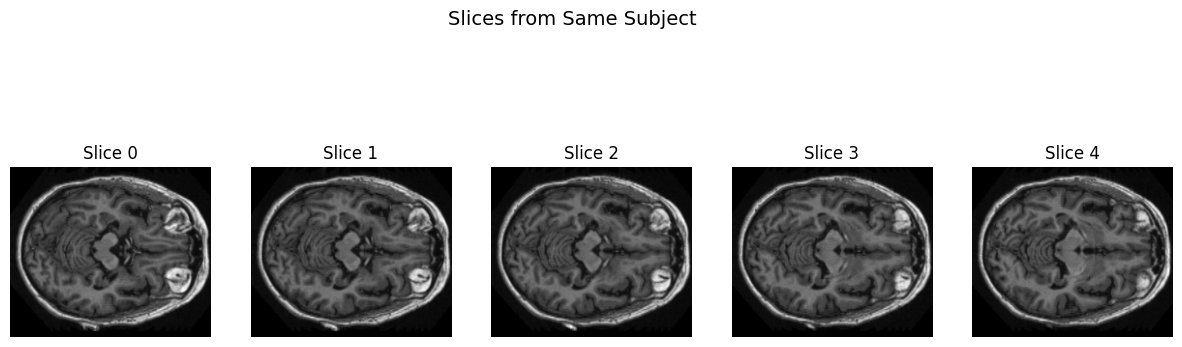

In [9]:
import matplotlib.pyplot as plt

# Pick one subject ID
subject_id = dataset_2d_with_subject[0][2]

# Get all slices of this subject
subject_slices = [x[0] for x in dataset_2d_with_subject if x[2] == subject_id]

fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for i in range(5):
    axes[i].imshow(subject_slices[i], cmap='gray')
    axes[i].set_title(f"Slice {i}")
    axes[i].axis('off')

plt.suptitle("Slices from Same Subject", fontsize=14)
plt.show()

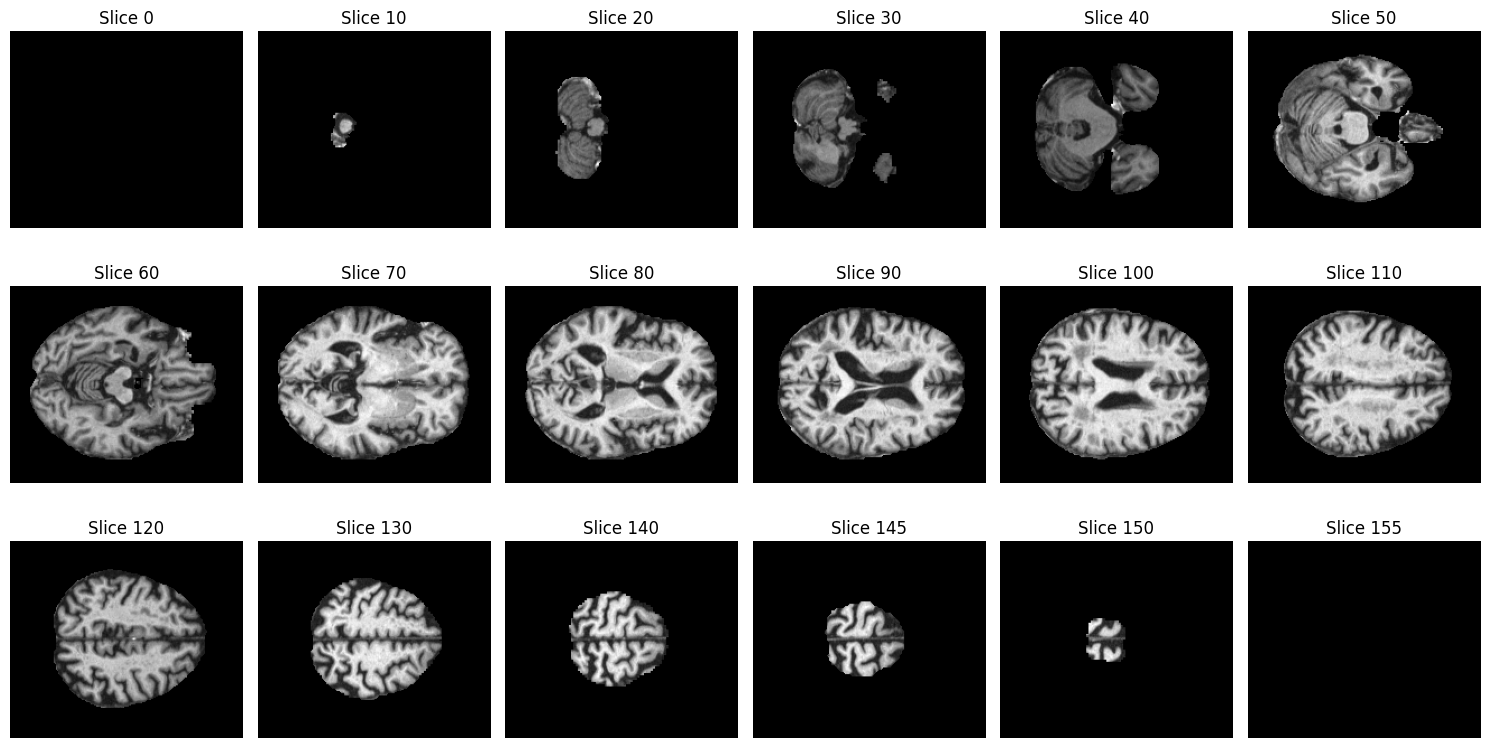

In [10]:
import matplotlib.pyplot as plt

img3d = image[..., 0] if image.ndim == 4 else image

fig, axes = plt.subplots(3, 6, figsize=(15, 8))

slice_indices = [0,10,20,30, 40, 50, 60, 70, 80,
                 90, 100, 110, 120, 130, 140,
                 145, 150, 155, 160, 165, 170]

for ax, idx in zip(axes.flat, slice_indices):
    ax.imshow(img3d[:, :, idx], cmap="gray")
    ax.set_title(f"Slice {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Strict subject-level splitting

Splits operate on patient IDs—not on raw slice rows—preventing leakage where two slices from the same brain appear in contradicting subsets.

Leakage artificially lowers error and violates scientific integrity; interviewer panels often probe precisely this safeguard.

In [11]:
all_subject_ids = sorted(list(set([x[2] for x in dataset_2d_with_subject])))

train_subjects, test_subjects = train_test_split(
    all_subject_ids, test_size=0.2, random_state=42
)

train_subjects, val_subjects = train_test_split(
    train_subjects, test_size=0.25, random_state=42
)

print("Train subjects:", len(train_subjects))
print("Val subjects:", len(val_subjects))
print("Test subjects:", len(test_subjects))

Train subjects: 23
Val subjects: 8
Test subjects: 8


### Materialize tensor splits

Construct `train_*`, `val_*`, `test_*` tensors mirroring the subject partitions.

Consistency ensures every backbone ingests identical sample order statistics apart from RNG tied to stochastic augmentations seeded earlier.

In [12]:
train_data = [x for x in dataset_2d_with_subject if x[2] in train_subjects]
val_data   = [x for x in dataset_2d_with_subject if x[2] in val_subjects]
test_data  = [x for x in dataset_2d_with_subject if x[2] in test_subjects]

print("Train slices:", len(train_data))
print("Val slices:", len(val_data))
print("Test slices:", len(test_data))

Train slices: 1840
Val slices: 640
Test slices: 640


### Torchvision transforms

Key ideas (see code unchanged):

**Resize → 224×224** aligns field-of-view receptive sizes across networks.

**Gray → pseudo-RGB duplication** aligns channel expectations of ImageNet-transfer CNNs trained on RGB photos (**transfer learning**): early filters encode generic contours still relevant to anatomical slabs.

Training-only **affine jitter** mildly increases variability without anatomically unrealistic flips contradictory to neuroscience constraints here.

Normalize using standard ImageNet mean/variance. **Why pretrained normalization:** aligns tensor statistics so fine-tuned early layers behave as intended.

In [13]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

### Dataset wrapper (`BrainAgeDataset`)

Encapsulates `__getitem__` logic yielding `(tensor, age, subject_id)` for each sample.

Isolation keeps dataloaders readable and aligns with textbook PyTorch design interviewers recognize instantly.

In [14]:
class BrainAgeDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        slice_2d, age, subject_id = self.data[idx]

        slice_2d = (slice_2d * 255).astype(np.uint8)

        if self.transform:
            image = self.transform(slice_2d)
        else:
            image = torch.tensor(slice_2d, dtype=torch.float32).unsqueeze(0)

        age = torch.tensor(age, dtype=torch.float32)

        return image, age, subject_id

### Instantiate loaders

Batch tensors should present shape `[batch, 3, 224, 224]` before backbone forward passes. **Why verify early:** avoids debugging long training runs when the real issue was a shape mismatch.

---

## Modeling strategy — architecture comparison Phase 1

| Model | Intuition |
| ------ | --------- |
| **Custom CNN** | Lightweight stack trained scratch—**baseline** showing learning without pretrained knowledge. |
| **ResNet18 / ResNet34** | Deep nets with **skip connections** smoothing optimization; residual pathways let gradients propagate through many layers (**ResNet ~ Residual Network**). Deeper stacks (34) may capture finer hierarchy at higher compute/memory. |
| **DenseNet121** | Dense wiring reuses representations across depths—alternative inductive bias favoring progressive feature refinement. |
| **EfficientNet-B0** | Compound-scaled backbone balancing predictive quality vs throughput—popular strong default convolutional learner. |

**Phase 1 = compare & choose**, not exhaustive hyperparameter pursuit—that discipline belongs to Notebook 2 anchored on one winner.

In [15]:
train_dataset = BrainAgeDataset(train_data, transform=train_transform)
val_dataset   = BrainAgeDataset(val_data, transform=eval_transform)
test_dataset  = BrainAgeDataset(test_data, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

images, ages, subject_ids = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch ages shape:", ages.shape)
print("Example subject ids:", subject_ids[:3])

Batch image shape: torch.Size([16, 3, 224, 224])
Batch ages shape: torch.Size([16])
Example subject ids: ('OAS1_0020_MR1', 'OAS1_0013_MR1', 'OAS1_0011_MR1')


### Factory helper `build_model`

Single entry point switching string names (`"resnet18"`, `"resnet34"`, `"densenet121"`, `"efficientnet_b0"`), swapping final linear heads for regression.

Minimizes copy/paste divergence during controlled experiments reviewers reward.

In [16]:
def build_model(model_name="resnet18"):
    if model_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, 1)

    elif model_name == "resnet34":
        model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, 1)

    elif model_name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, 1)

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)

    else:
        raise ValueError("Unknown model name")

    return model

In [17]:
def train_one_epoch_scratch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for batch in loader:
        images = batch[0].to(device)
        targets = batch[1].to(device).float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)

In [18]:
def validate_one_epoch_scratch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds = []
    targets_all = []

    with torch.no_grad():
        for batch in loader:
            images = batch[0].to(device)
            targets = batch[1].to(device).float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * images.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            targets_all.extend(targets.squeeze(1).cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    mae = np.mean(np.abs(np.array(preds) - np.array(targets_all)))

    return epoch_loss, mae

In [19]:
from collections import defaultdict
import numpy as np
import torch

def evaluate_subject_mae(model, loader, device, agg="mean"):
    model.eval()
    subject_preds = defaultdict(list)
    subject_true = {}

    with torch.no_grad():
        for batch in loader:
            images = batch[0].to(device)
            ages = batch[1].numpy()
            subject_ids = batch[2]

            outputs = model(images).squeeze(1).cpu().numpy()

            for pred, age, sid in zip(outputs, ages, subject_ids):
                subject_preds[sid].append(pred)
                subject_true[sid] = age

    errors = []

    for sid in subject_preds:
        preds = np.array(subject_preds[sid])

        if agg == "mean":
            final_pred = preds.mean()
        elif agg == "median":
            final_pred = np.median(preds)
        else:
            raise ValueError("agg must be 'mean' or 'median'")

        errors.append(abs(final_pred - subject_true[sid]))

    return np.mean(errors)

## Phase 1 comparative experiments — reading guide

The next blocks are a controlled comparison on **one disc (~35 subjects)**.

Why this setup is intentional:

- MRI deep learning training is computationally expensive.
- A reduced but valid subset gives quick, reliable ranking of architectures.
- We can identify promising models early before spending heavy compute.

Tested in this phase:

- Custom CNN (baseline)
- ResNet18
- ResNet34
- DenseNet121
- EfficientNet-B0

This phase answers: **which architecture should receive full-scale training?**

---

## Experiment A — Custom CNN baseline (train from scratch)

**What:** small convolutional network with random initialization.

**Why include it:** it provides a baseline and shows the gain from transfer learning.

In [20]:
#MODEL DEFINITION CELL
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.regressor(x)
        return x

In [21]:
#INITIALIZATION CELL
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_scratch = SimpleCNN().to(device)

criterion_scratch = nn.SmoothL1Loss()
optimizer_scratch = torch.optim.Adam(model_scratch.parameters(), lr=1e-4)

print(model_scratch)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (regressor): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [22]:
#TRAINING CELL
num_epochs = 15

best_val_subject_mae_scratch = float("inf")

train_losses_scratch = []
val_losses_scratch = []
val_slice_maes_scratch = []
val_subject_maes_scratch = []

for epoch in range(num_epochs):

    train_loss = train_one_epoch_scratch(
        model_scratch, train_loader, criterion_scratch, optimizer_scratch, device
    )

    val_loss, val_slice_mae = validate_one_epoch_scratch(
        model_scratch, val_loader, criterion_scratch, device
    )

    val_subject_mae = evaluate_subject_mae(
        model_scratch, val_loader, device, agg="mean"
    )

    train_losses_scratch.append(train_loss)
    val_losses_scratch.append(val_loss)
    val_slice_maes_scratch.append(val_slice_mae)
    val_subject_maes_scratch.append(val_subject_mae)

    print(f"Scratch CNN | Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Slice MAE: {val_slice_mae:.4f}")
    print(f"Val Subject MAE: {val_subject_mae:.4f}")
    print("-" * 40)

    if val_subject_mae < best_val_subject_mae_scratch:
        best_val_subject_mae_scratch = val_subject_mae
        torch.save(model_scratch.state_dict(), "best_scratch_cnn.pth")
        print("Best Scratch CNN model saved.")

Scratch CNN | Epoch 1/15
Train Loss: 51.3214
Val Loss: 37.0177
Val Slice MAE: 37.5131
Val Subject MAE: 37.3405
----------------------------------------
Best Scratch CNN model saved.
Scratch CNN | Epoch 2/15
Train Loss: 20.8010
Val Loss: 25.6050
Val Slice MAE: 26.1050
Val Subject MAE: 26.1050
----------------------------------------
Best Scratch CNN model saved.
Scratch CNN | Epoch 3/15
Train Loss: 18.9468
Val Loss: 26.1470
Val Slice MAE: 26.6470
Val Subject MAE: 26.6470
----------------------------------------
Scratch CNN | Epoch 4/15
Train Loss: 18.9625
Val Loss: 26.1865
Val Slice MAE: 26.6865
Val Subject MAE: 26.6865
----------------------------------------
Scratch CNN | Epoch 5/15
Train Loss: 18.8122
Val Loss: 24.5482
Val Slice MAE: 25.0482
Val Subject MAE: 25.0482
----------------------------------------
Best Scratch CNN model saved.
Scratch CNN | Epoch 6/15
Train Loss: 18.8427
Val Loss: 26.0293
Val Slice MAE: 26.5293
Val Subject MAE: 26.5293
---------------------------------------

In [23]:
model_scratch.load_state_dict(torch.load("best_scratch_cnn.pth", map_location=device))
model_scratch.eval()

test_loss_scratch, test_slice_mae_scratch = validate_one_epoch_scratch(
    model_scratch, test_loader, criterion_scratch, device
)

test_subject_mae_scratch = evaluate_subject_mae(
    model_scratch, test_loader, device, agg="mean"
)

print("Scratch CNN Test Loss:", test_loss_scratch)
print("Scratch CNN Test Slice MAE:", test_slice_mae_scratch)
print("Scratch CNN Test Subject MAE:", test_subject_mae_scratch)

Scratch CNN Test Loss: 28.718872928619383
Scratch CNN Test Slice MAE: 29.218872
Scratch CNN Test Subject MAE: 29.218874


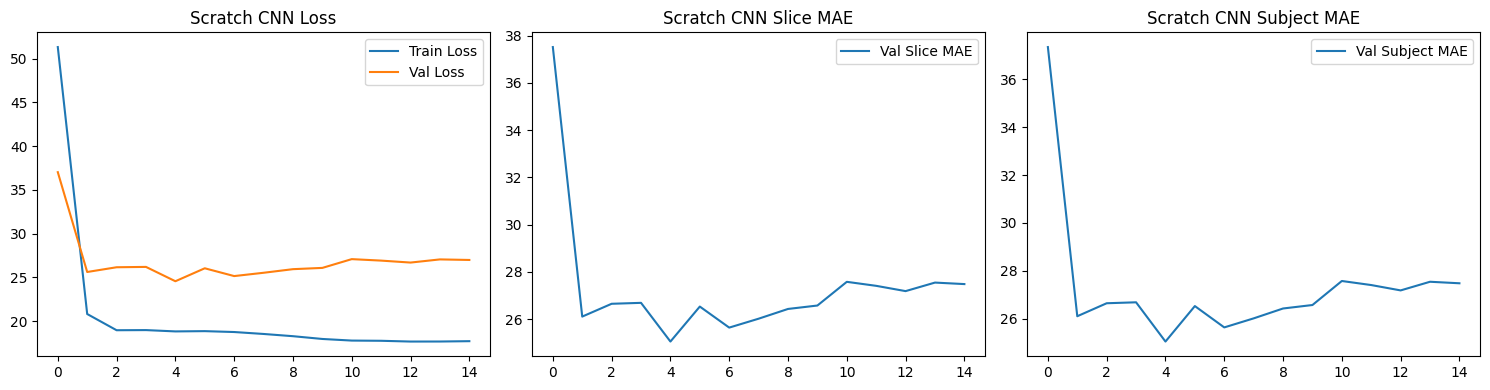

In [24]:
#PLOT CELL (optional but strongly recommended)
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(train_losses_scratch, label="Train Loss")
plt.plot(val_losses_scratch, label="Val Loss")
plt.title("Scratch CNN Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(val_slice_maes_scratch, label="Val Slice MAE")
plt.title("Scratch CNN Slice MAE")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(val_subject_maes_scratch, label="Val Subject MAE")
plt.title("Scratch CNN Subject MAE")
plt.legend()

plt.tight_layout()
plt.show()

## Experiment B — ResNet18 pretrained backbone

Loads ImageNet-pretrained residual CNN for fine-tuned regression.

Remaining Phase 1 blocks repeat the scaffolding for progressively different depths / wiring (ResNet34, DenseNet121, EfficientNet-B0)—only **`build_model` selection** swaps.

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = build_model("resnet18").to(device)

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


### Training Setup elements

**Loss — Smooth L1**

Behaves softly around small residuals yet caps extreme gradient spikes vs pure squared error—helpful given slice heterogeneity. **Reported KPI remains MAE in years.**

**Optimizer — Adam (`1e-4`)**

Adaptive per-parameter scaling fits rapid prototyped fine-tuning; mild LR suits pretrained filters.

**Implicit regularizers:** pretrained convolutional kernels, stochastic augmentations, subject-disjoint splits, selecting checkpoints on validation—not training—subject MAE.

These choices prioritize stable optimization coupled with clinician-interpretable error magnitudes.

In [26]:
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

### Separation of train vs validate helpers

Training functions enable gradients & weight updates (**`train` mode**). Validation stays in **`eval`** + `torch.no_grad()` to quantify generalization absent parameter mutation.

Readers should never accidentally backpropagate through validation minibatches—that invalidates benchmarking.

In [27]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, ages, _ in loader:
        images = images.to(device)
        ages = ages.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, ages)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, ages, _ in loader:
            images = images.to(device)
            ages = ages.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, ages)

            running_loss += loss.item() * images.size(0)

            all_preds.extend(outputs.squeeze(1).cpu().numpy())
            all_targets.extend(ages.squeeze(1).cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    mae = np.mean(np.abs(np.array(all_preds) - np.array(all_targets)))

    return epoch_loss, mae

### Subject-level aggregation & MAE

Average (or configurable median) merges slice-wise predictions belonging to identical subject IDs before averaging absolute errors. **Why aggregate:** aligns predictions with clinically meaningful granularity (single chronological age).

In [28]:
def evaluate_subject_mae(model, loader, device, agg="mean"):
    model.eval()
    subject_preds = defaultdict(list)
    subject_true = {}

    with torch.no_grad():
        for images, ages, subject_ids in loader:
            images = images.to(device)
            outputs = model(images).squeeze(1).cpu().numpy()
            ages = ages.numpy()

            for pred, age, sid in zip(outputs, ages, subject_ids):
                subject_preds[sid].append(pred)
                subject_true[sid] = age

    errors = []

    for sid in subject_preds:
        preds = np.array(subject_preds[sid])

        if agg == "mean":
            final_pred = preds.mean()
        elif agg == "median":
            final_pred = np.median(preds)
        else:
            raise ValueError("Unknown aggregation")

        true_age = subject_true[sid]
        errors.append(abs(final_pred - true_age))

    return float(np.mean(errors))

### Checkpointing disciplined by metric

Logs train loss plus slice cues, yet saves artifacts when validation **subject** MAE improves.

Final epoch weights can overfit mildly; reloading best-validation snapshot reports honest leaderboard capacity.

In [29]:
num_epochs = 15
best_val_subject_mae = float("inf")

train_losses = []
val_losses = []
val_slice_maes = []
val_subject_maes = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_slice_mae = validate_one_epoch(model, val_loader, criterion, device)
    val_subject_mae = evaluate_subject_mae(model, val_loader, device, agg="mean")

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_slice_maes.append(val_slice_mae)
    val_subject_maes.append(val_subject_mae)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Slice MAE: {val_slice_mae:.4f}")
    print(f"Val Subject MAE: {val_subject_mae:.4f}")
    print("-" * 40)

    if val_subject_mae < best_val_subject_mae:
        best_val_subject_mae = val_subject_mae
        torch.save(model.state_dict(), "best_resnet18_brain_age.pth")
        print("Best model saved.")

Epoch 1/15
Train Loss: 50.9429
Val Loss: 50.8959
Val Slice MAE: 51.3959
Val Subject MAE: 51.3959
----------------------------------------
Best model saved.
Epoch 2/15
Train Loss: 43.8770
Val Loss: 44.2353
Val Slice MAE: 44.7353
Val Subject MAE: 44.7353
----------------------------------------
Best model saved.
Epoch 3/15
Train Loss: 37.0185
Val Loss: 38.9638
Val Slice MAE: 39.4638
Val Subject MAE: 39.4638
----------------------------------------
Best model saved.
Epoch 4/15
Train Loss: 29.8676
Val Loss: 29.2673
Val Slice MAE: 29.7452
Val Subject MAE: 29.6700
----------------------------------------
Best model saved.
Epoch 5/15
Train Loss: 21.5109
Val Loss: 22.0646
Val Slice MAE: 22.5608
Val Subject MAE: 22.4489
----------------------------------------
Best model saved.
Epoch 6/15
Train Loss: 12.8788
Val Loss: 16.8017
Val Slice MAE: 17.2939
Val Subject MAE: 17.1303
----------------------------------------
Best model saved.
Epoch 7/15
Train Loss: 7.1237
Val Loss: 8.4874
Val Slice MAE: 8.

### Restore best checkpoint

Reload saved weights preceding test evaluation—not necessarily the concluding epoch tensors.

In [30]:
model.load_state_dict(torch.load("best_resnet18_brain_age.pth", map_location=device))
model = model.to(device)
model.eval()
print("Best ResNet18 model loaded.")

Best ResNet18 model loaded.


### Held-out testing

Produce slice & subject summaries; elevate **subject** MAE interpreting architecture quality fairly.

In [31]:
test_loss, test_slice_mae = validate_one_epoch(model, test_loader, criterion, device)
test_subject_mae = evaluate_subject_mae(model, test_loader, device, agg="mean")

print("Test Loss:", test_loss)
print("Test Slice MAE:", test_slice_mae)
print("Test Subject MAE:", test_subject_mae)

Test Loss: 8.015597073733806
Test Slice MAE: 8.492824
Test Subject MAE: 7.535493850708008


### Diagnostic plotting

Visualization clarifies convergence speed, divergence, plateauing validation subject curves, widening train-vs-val gaps implying overfitting risk.

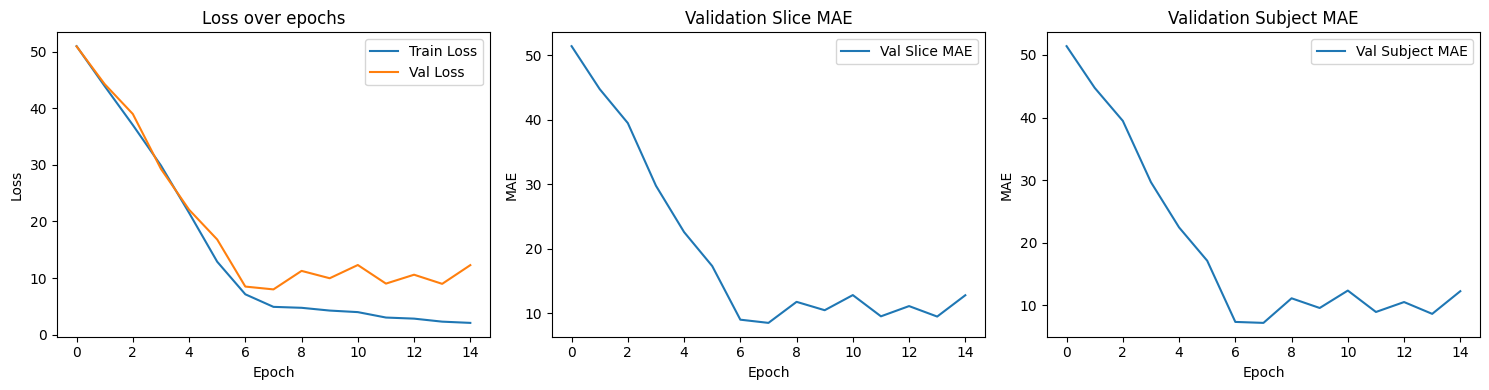

In [32]:
plt.figure(figsize=(15, 4))

# 1. Loss curves
plt.subplot(1, 3, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# 2. Slice MAE
plt.subplot(1, 3, 2)
plt.plot(val_slice_maes, label="Val Slice MAE")
plt.title("Validation Slice MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

# 3. Subject MAE (MOST IMPORTANT)
plt.subplot(1, 3, 3)
plt.plot(val_subject_maes, label="Val Subject MAE")
plt.title("Validation Subject MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()

Number of predictions: 640
Number of targets: 640


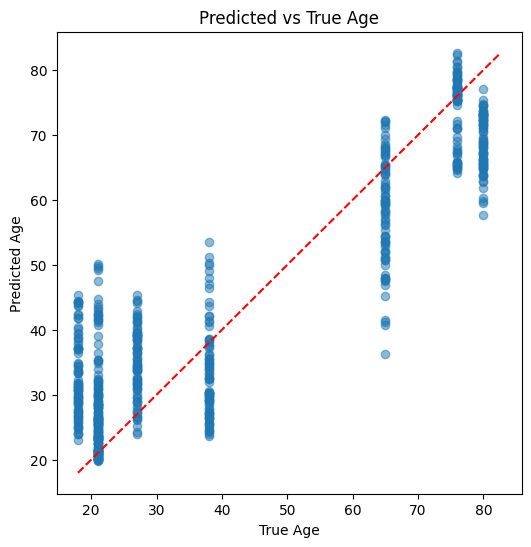

In [33]:
%matplotlib inline

def plot_predictions(model, loader, device):
    model.eval()
    preds = []
    targets = []

    with torch.no_grad():
        for images, ages, _ in loader:
            images = images.to(device)
            outputs = model(images).squeeze(1).cpu().numpy()
            preds.extend(outputs.tolist())
            targets.extend(ages.numpy().tolist())

    print("Number of predictions:", len(preds))
    print("Number of targets:", len(targets))

    if len(preds) == 0:
        print("No predictions found.")
        return

    plt.figure(figsize=(6, 6))
    plt.scatter(targets, preds, alpha=0.5)
    plt.xlabel("True Age")
    plt.ylabel("Predicted Age")
    plt.title("Predicted vs True Age")

    min_val = min(min(targets), min(preds))
    max_val = max(max(targets), max(preds))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.show()

plot_predictions(model, test_loader, device)

### Predicted-vs-true scatter (sanity visualization)

Diagonal proximity indicates calibrated predictions. **Compare models:** narrower clouds and fewer systematic offsets imply better generalization on identical withheld slices.

## Experiment C — ResNet34

**Difference vs B:** deeper residual backbone.

**Hypothesis:** deeper capacity fits richer morphology if the data support it; empirical MAE settles the trade-off vs compute.

In [34]:
#Cell 1 — model + optimizer

model_resnet34 = build_model("resnet34").to(device)

criterion_resnet34 = nn.SmoothL1Loss()
optimizer_resnet34 = torch.optim.Adam(model_resnet34.parameters(), lr=1e-4)

print(model_resnet34.__class__.__name__)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 159MB/s] 


ResNet


In [35]:
#Cell 2 — training

num_epochs = 15
best_val_subject_mae_resnet34 = float("inf")

train_losses_resnet34 = []
val_losses_resnet34 = []
val_slice_maes_resnet34 = []
val_subject_maes_resnet34 = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model_resnet34, train_loader, criterion_resnet34, optimizer_resnet34, device)
    val_loss, val_slice_mae = validate_one_epoch(model_resnet34, val_loader, criterion_resnet34, device)
    val_subject_mae = evaluate_subject_mae(model_resnet34, val_loader, device, agg="mean")

    train_losses_resnet34.append(train_loss)
    val_losses_resnet34.append(val_loss)
    val_slice_maes_resnet34.append(val_slice_mae)
    val_subject_maes_resnet34.append(val_subject_mae)

    print(f"ResNet34 | Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Slice MAE: {val_slice_mae:.4f}")
    print(f"Val Subject MAE: {val_subject_mae:.4f}")
    print("-" * 40)

    if val_subject_mae < best_val_subject_mae_resnet34:
        best_val_subject_mae_resnet34 = val_subject_mae
        torch.save(model_resnet34.state_dict(), "best_resnet34_brain_age.pth")
        print("Best ResNet34 model saved.")

ResNet34 | Epoch 1/15
Train Loss: 47.5524
Val Loss: 47.4457
Val Slice MAE: 47.9457
Val Subject MAE: 47.9457
----------------------------------------
Best ResNet34 model saved.
ResNet34 | Epoch 2/15
Train Loss: 38.8709
Val Loss: 39.3685
Val Slice MAE: 39.8572
Val Subject MAE: 39.8572
----------------------------------------
Best ResNet34 model saved.
ResNet34 | Epoch 3/15
Train Loss: 31.2748
Val Loss: 31.1565
Val Slice MAE: 31.6462
Val Subject MAE: 31.4171
----------------------------------------
Best ResNet34 model saved.
ResNet34 | Epoch 4/15
Train Loss: 23.0549
Val Loss: 32.8251
Val Slice MAE: 33.3211
Val Subject MAE: 33.2556
----------------------------------------
ResNet34 | Epoch 5/15
Train Loss: 14.2288
Val Loss: 9.5711
Val Slice MAE: 10.0577
Val Subject MAE: 9.5919
----------------------------------------
Best ResNet34 model saved.
ResNet34 | Epoch 6/15
Train Loss: 8.0620
Val Loss: 8.4347
Val Slice MAE: 8.9249
Val Subject MAE: 8.5188
----------------------------------------
Best

In [36]:
#Cell 3 — load best model

model_resnet34.load_state_dict(torch.load("best_resnet34_brain_age.pth", map_location=device))
model_resnet34 = model_resnet34.to(device)
model_resnet34.eval()

print("Best ResNet34 model loaded.")

Best ResNet34 model loaded.


In [37]:
#Cell 4 — test evaluation

test_loss_resnet34, test_slice_mae_resnet34 = validate_one_epoch(model_resnet34, test_loader, criterion_resnet34, device)
test_subject_mae_resnet34 = evaluate_subject_mae(model_resnet34, test_loader, device, agg="mean")

print("ResNet34 Test Loss:", test_loss_resnet34)
print("ResNet34 Test Slice MAE:", test_slice_mae_resnet34)
print("ResNet34 Test Subject MAE:", test_subject_mae_resnet34)

ResNet34 Test Loss: 7.512373293936252
ResNet34 Test Slice MAE: 7.9958696
ResNet34 Test Subject MAE: 7.220213890075684


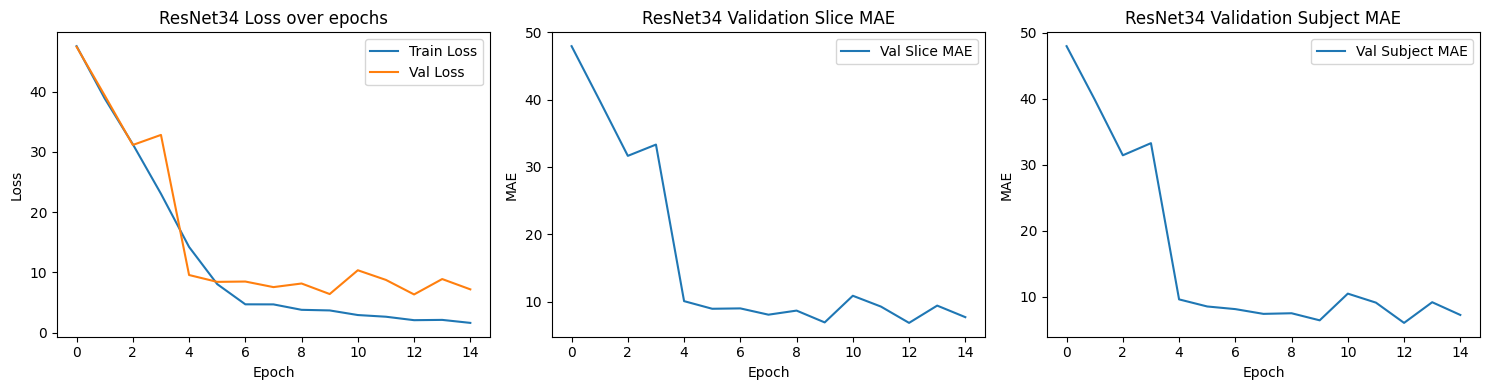

In [38]:
#Cell 5 — plots

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(train_losses_resnet34, label="Train Loss")
plt.plot(val_losses_resnet34, label="Val Loss")
plt.title("ResNet34 Loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(val_slice_maes_resnet34, label="Val Slice MAE")
plt.title("ResNet34 Validation Slice MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(val_subject_maes_resnet34, label="Val Subject MAE")
plt.title("ResNet34 Validation Subject MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()

Number of predictions: 640
Number of targets: 640


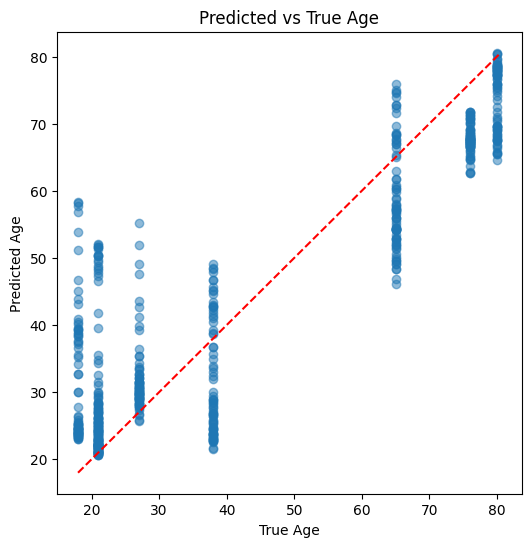

In [39]:
#Cell 6 — predicted vs true

plot_predictions(model_resnet34, test_loader, device)

## Experiment D — DenseNet121

**Interpretation framing:** contrasts dense shortcut feature reuse versus residual summation philosophies.

Observe whether redundancy patterns improve age-sensitive representations on OASIS slices—a scientific story beyond raw leaderboard rank.

In [40]:
#Cell 1 — model + optimizer

model_densenet121 = build_model("densenet121").to(device)

criterion_densenet121 = nn.SmoothL1Loss()
optimizer_densenet121 = torch.optim.Adam(model_densenet121.parameters(), lr=1e-4)

print(model_densenet121.__class__.__name__)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 169MB/s]


DenseNet


In [41]:
#Cell 2 — training

num_epochs = 15
best_val_subject_mae_densenet121 = float("inf")

train_losses_densenet121 = []
val_losses_densenet121 = []
val_slice_maes_densenet121 = []
val_subject_maes_densenet121 = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model_densenet121, train_loader, criterion_densenet121, optimizer_densenet121, device)
    val_loss, val_slice_mae = validate_one_epoch(model_densenet121, val_loader, criterion_densenet121, device)
    val_subject_mae = evaluate_subject_mae(model_densenet121, val_loader, device, agg="mean")

    train_losses_densenet121.append(train_loss)
    val_losses_densenet121.append(val_loss)
    val_slice_maes_densenet121.append(val_slice_mae)
    val_subject_maes_densenet121.append(val_subject_mae)

    print(f"DenseNet121 | Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Slice MAE: {val_slice_mae:.4f}")
    print(f"Val Subject MAE: {val_subject_mae:.4f}")
    print("-" * 40)

    if val_subject_mae < best_val_subject_mae_densenet121:
        best_val_subject_mae_densenet121 = val_subject_mae
        torch.save(model_densenet121.state_dict(), "best_densenet121_brain_age.pth")
        print("Best DenseNet121 model saved.")

DenseNet121 | Epoch 1/15
Train Loss: 51.8657
Val Loss: 52.2237
Val Slice MAE: 52.7237
Val Subject MAE: 52.7237
----------------------------------------
Best DenseNet121 model saved.
DenseNet121 | Epoch 2/15
Train Loss: 44.6275
Val Loss: 45.1778
Val Slice MAE: 45.6778
Val Subject MAE: 45.6778
----------------------------------------
Best DenseNet121 model saved.
DenseNet121 | Epoch 3/15
Train Loss: 36.9890
Val Loss: 38.4972
Val Slice MAE: 38.9930
Val Subject MAE: 38.9928
----------------------------------------
Best DenseNet121 model saved.
DenseNet121 | Epoch 4/15
Train Loss: 29.0675
Val Loss: 28.9495
Val Slice MAE: 29.4412
Val Subject MAE: 29.0858
----------------------------------------
Best DenseNet121 model saved.
DenseNet121 | Epoch 5/15
Train Loss: 20.2868
Val Loss: 20.7773
Val Slice MAE: 21.2720
Val Subject MAE: 20.9077
----------------------------------------
Best DenseNet121 model saved.
DenseNet121 | Epoch 6/15
Train Loss: 12.7526
Val Loss: 24.4767
Val Slice MAE: 24.9755
Val 

In [42]:
#Cell 3 — load best model

model_densenet121.load_state_dict(torch.load("best_densenet121_brain_age.pth", map_location=device))
model_densenet121 = model_densenet121.to(device)
model_densenet121.eval()

print("Best DenseNet121 model loaded.")

Best DenseNet121 model loaded.


In [43]:
#Cell 4 — test evaluation

test_loss_densenet121, test_slice_mae_densenet121 = validate_one_epoch(
    model_densenet121, test_loader, criterion_densenet121, device
)
test_subject_mae_densenet121 = evaluate_subject_mae(
    model_densenet121, test_loader, device, agg="mean"
)

print("DenseNet121 Test Loss:", test_loss_densenet121)
print("DenseNet121 Test Slice MAE:", test_slice_mae_densenet121)
print("DenseNet121 Test Subject MAE:", test_subject_mae_densenet121)

DenseNet121 Test Loss: 8.216930294036866
DenseNet121 Test Slice MAE: 8.6981735
DenseNet121 Test Subject MAE: 8.046390533447266


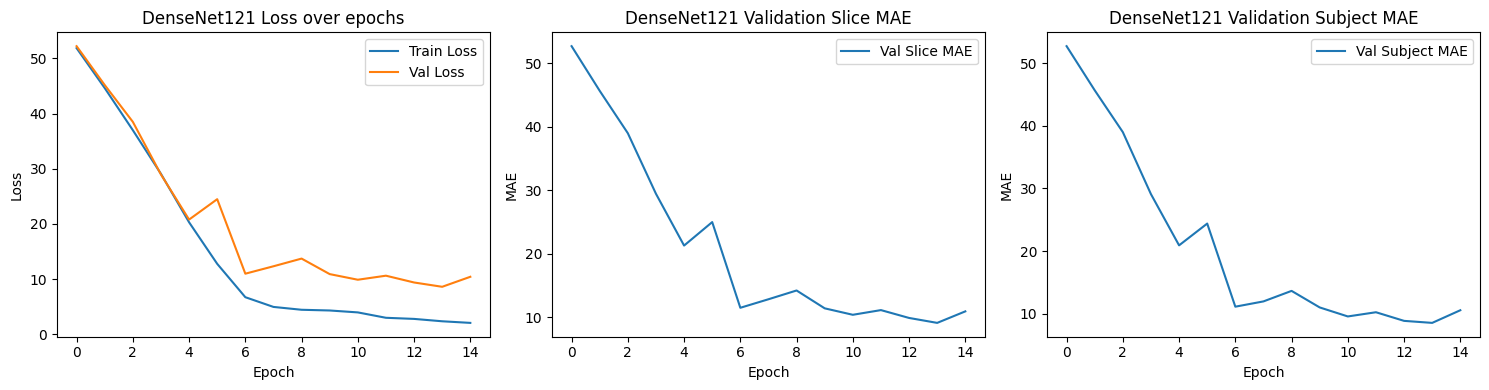

In [44]:
#Cell 5 — plots

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(train_losses_densenet121, label="Train Loss")
plt.plot(val_losses_densenet121, label="Val Loss")
plt.title("DenseNet121 Loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(val_slice_maes_densenet121, label="Val Slice MAE")
plt.title("DenseNet121 Validation Slice MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(val_subject_maes_densenet121, label="Val Subject MAE")
plt.title("DenseNet121 Validation Subject MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()

Number of predictions: 640
Number of targets: 640


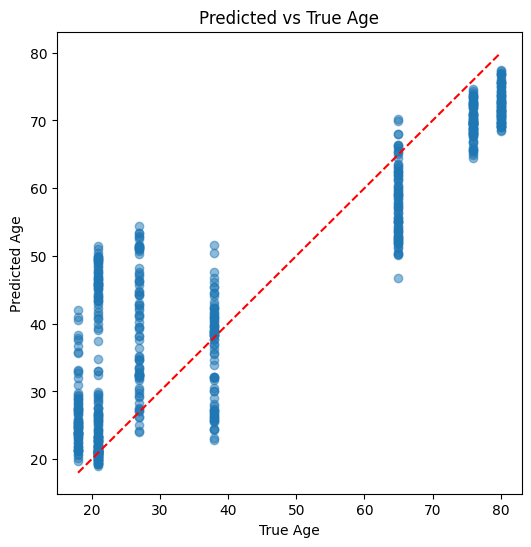

In [45]:
#Cell 6 — predicted vs true

plot_predictions(model_densenet121, test_loader, device)

## Experiment E — EfficientNet-B0

Balances accuracy and efficiency. **Benchmark expectation:** a historically strong contender among compact CNN policies; the printed Phase 1 results judge that claim on identical pipelines versus the other contenders here.

In [46]:
#Cell 1 — model + optimizer

model_efficientnet = build_model("efficientnet_b0").to(device)

criterion_efficientnet = nn.SmoothL1Loss()
optimizer_efficientnet = torch.optim.Adam(model_efficientnet.parameters(), lr=1e-4)

print(model_efficientnet.__class__.__name__)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 134MB/s] 


EfficientNet


In [47]:
#Cell 2 — training

num_epochs = 15
best_val_subject_mae_eff = float("inf")

train_losses_eff = []
val_losses_eff = []
val_slice_maes_eff = []
val_subject_maes_eff = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model_efficientnet, train_loader, criterion_efficientnet, optimizer_efficientnet, device)
    val_loss, val_slice_mae = validate_one_epoch(model_efficientnet, val_loader, criterion_efficientnet, device)
    val_subject_mae = evaluate_subject_mae(model_efficientnet, val_loader, device, agg="mean")

    train_losses_eff.append(train_loss)
    val_losses_eff.append(val_loss)
    val_slice_maes_eff.append(val_slice_mae)
    val_subject_maes_eff.append(val_subject_mae)

    print(f"EfficientNet-B0 | Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Slice MAE: {val_slice_mae:.4f}")
    print(f"Val Subject MAE: {val_subject_mae:.4f}")
    print("-" * 40)

    if val_subject_mae < best_val_subject_mae_eff:
        best_val_subject_mae_eff = val_subject_mae
        torch.save(model_efficientnet.state_dict(), "best_efficientnet_b0_brain_age.pth")
        print("Best EfficientNet-B0 model saved.")

EfficientNet-B0 | Epoch 1/15
Train Loss: 50.8730
Val Loss: 48.1722
Val Slice MAE: 48.6722
Val Subject MAE: 48.6722
----------------------------------------
Best EfficientNet-B0 model saved.
EfficientNet-B0 | Epoch 2/15
Train Loss: 40.8614
Val Loss: 41.0748
Val Slice MAE: 41.5557
Val Subject MAE: 41.4768
----------------------------------------
Best EfficientNet-B0 model saved.
EfficientNet-B0 | Epoch 3/15
Train Loss: 33.9844
Val Loss: 34.7449
Val Slice MAE: 35.2369
Val Subject MAE: 35.2134
----------------------------------------
Best EfficientNet-B0 model saved.
EfficientNet-B0 | Epoch 4/15
Train Loss: 27.8776
Val Loss: 29.3191
Val Slice MAE: 29.8153
Val Subject MAE: 29.6839
----------------------------------------
Best EfficientNet-B0 model saved.
EfficientNet-B0 | Epoch 5/15
Train Loss: 21.8872
Val Loss: 24.4292
Val Slice MAE: 24.9235
Val Subject MAE: 24.0220
----------------------------------------
Best EfficientNet-B0 model saved.
EfficientNet-B0 | Epoch 6/15
Train Loss: 16.1650
V

In [48]:
#Cell 3 — load best model

model_efficientnet.load_state_dict(torch.load("best_efficientnet_b0_brain_age.pth", map_location=device))
model_efficientnet = model_efficientnet.to(device)
model_efficientnet.eval()

print("Best EfficientNet-B0 model loaded.")

Best EfficientNet-B0 model loaded.


In [49]:
#Cell 4 — test evaluation

test_loss_eff, test_slice_mae_eff = validate_one_epoch(
    model_efficientnet, test_loader, criterion_efficientnet, device
)

test_subject_mae_eff = evaluate_subject_mae(
    model_efficientnet, test_loader, device, agg="mean"
)

print("EfficientNet-B0 Test Loss:", test_loss_eff)
print("EfficientNet-B0 Test Slice MAE:", test_slice_mae_eff)
print("EfficientNet-B0 Test Subject MAE:", test_subject_mae_eff)

EfficientNet-B0 Test Loss: 7.293605464696884
EfficientNet-B0 Test Slice MAE: 7.770833
EfficientNet-B0 Test Subject MAE: 6.019491672515869


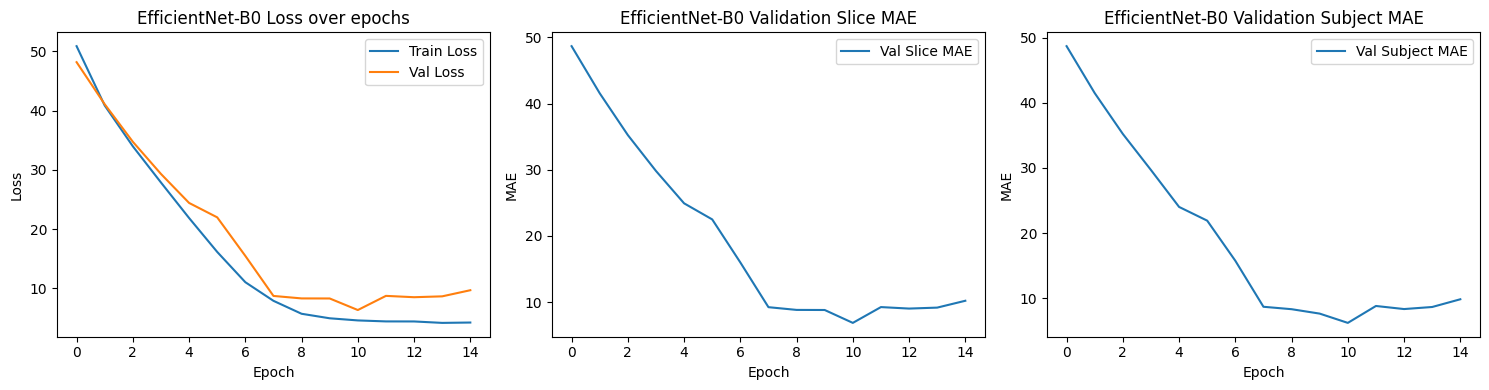

In [50]:
#Cell 5 — plots

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(train_losses_eff, label="Train Loss")
plt.plot(val_losses_eff, label="Val Loss")
plt.title("EfficientNet-B0 Loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(val_slice_maes_eff, label="Val Slice MAE")
plt.title("EfficientNet-B0 Validation Slice MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(val_subject_maes_eff, label="Val Subject MAE")
plt.title("EfficientNet-B0 Validation Subject MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()

Number of predictions: 640
Number of targets: 640


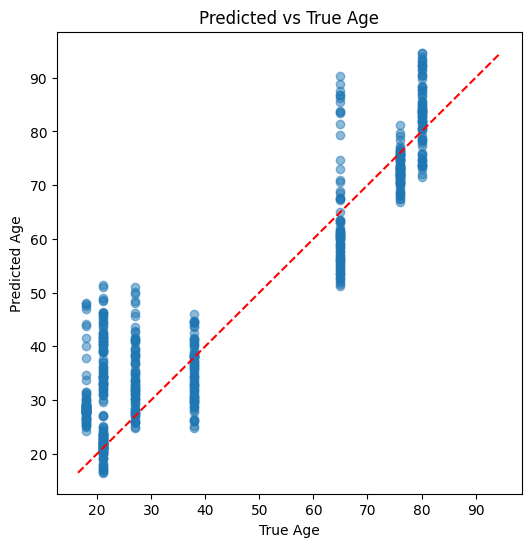

In [51]:
#Cell 6 — predicted vs true

plot_predictions(model_efficientnet, test_loader, device)

## Model comparison & best-model selection — Step 1 (one-disc benchmark)

**Protocol:** same split logic, preprocessing philosophy, and evaluation target (subject-level MAE).

**Subject-level test MAE (years), one-disc stage:**

| Model | Approx. MAE |
| --- | ---: |
| Custom CNN | ~29.22 |
| DenseNet121 | ~8.05 |
| ResNet18 | ~7.54 |
| ResNet34 | ~7.22 |
| **EfficientNet-B0** | **~6.02** |

### Decision from Step 1

**EfficientNet-B0 is selected as the best architecture** on the fast comparison benchmark.

This is exactly the objective of Step 1: identify the strongest backbone quickly and reliably.

---

## Step 2 Scaling the Selected Model to a Larger Dataset

After identifying EfficientNet-B0 as the most promising architecture during the initial comparison phase, we proceed to train it on a larger portion of the dataset.

This second step aims to evaluate how well the selected model generalizes when exposed to more data.

Training configuration:

**12 discs** (expanded OASIS dataset coverage)

**15 epochs**

Result on the larger dataset:

Test MAE: 4.59 years

This step validates the adopted strategy:

First, a quick comparison of multiple models using a smaller dataset to save time and computational resources
Then, a deeper training phase focused only on the best-performing model

This approach ensures efficient experimentation while still allowing the final model to benefit from a larger and more representative dataset.

## Evaluation metrics recap

To evaluate the model, we focus on Mean Absolute Error (MAE).

**Subject MAE (years):**

This is the main evaluation metric used in this project. Predictions are first made at the slice level, then averaged across all slices belonging to the same subject. The final error represents the average difference (in years) between this aggregated prediction and the true age.

**Slice MAE:**

This metric is computed at the image slice level.
It provides more detailed feedback during training but can be less reliable due to correlations between slices from the same subject.

**Training Loss (SmoothL1):**

The model is trained using Smooth L1 loss, which is a combination of L1 and L2 losses.
It helps make training more stable and less sensitive to large errors.

In this project, subject-level MAE is the most important metric, as it reflects the real prediction performance per individual.

## Conclusion — Notebook 1

This notebook presents a structured and efficient experimentation strategy for brain age prediction using MRI data.

The approach follows two key steps:

**Initial exploration:**
Several architectures were compared using a smaller dataset (~35 subjects) to quickly identify promising models while reducing computational cost.

**Focused scaling:**
The best-performing model, EfficientNet-B0, was then trained on a larger dataset (12 discs) for 15 epochs to evaluate its performance under more realistic conditions.

Key results:

EfficientNet-B0 was selected as the strongest model during the comparison phase
After scaling, it achieved a **Test Subject MAE of 4.59 years**

This strategy reflects a practical machine learning approach:

**first compare efficiently**,
**then invest resources in the best model**

Such decisions are especially important in MRI-based deep learning, where training is computationally expensive and time-consuming.

So the workflow is not defensive; it is deliberate and professional: **screen first, scale second**.

### Transition to Notebook 2

In the next phase, we focus on improving the selected model.

**EfficientNet-B0** will be further optimized using **hyperparameter tuning** (learning rate, regularization, dropout, etc.) to achieve better performance.

In [52]:
import os

dataset_root = "/kaggle/input/datasets/laabidiahmed/brain-aging-mri-dataset-oasis-all-discs"

print("Dataset root:", dataset_root)
print("Root contents:")
print(os.listdir(dataset_root))

Dataset root: /kaggle/input/datasets/laabidiahmed/brain-aging-mri-dataset-oasis-all-discs
Root contents:
['oasis_cross-sectional-5708aa0a98d82080.xlsx', 'oasis_cross-sectional_disc6', 'oasis_cross-sectional_disc12', 'oasis_cross-sectional_disc4', 'oasis_cross-sectional_disc8', 'oasis_cross-sectional_disc9', 'oasis_cross-sectional_disc11', 'oasis_cross-sectional_disc5', 'oasis_cross-sectional_disc3', 'oasis_cross-sectional_disc1', 'oasis_cross-sectional_disc2', 'oasis_cross-sectional_disc10', 'oasis_cross-sectional_disc7']


In [53]:
#Load Excel
import os
import pandas as pd

# Get all files in dataset root
all_files = os.listdir(dataset_root)

# Filter Excel files
excel_files = [f for f in all_files if f.endswith(".xlsx")]

print("Excel files found:", excel_files)

# Take the first Excel file
excel_path = os.path.join(dataset_root, excel_files[0])

# Load it
df = pd.read_excel(excel_path)

print("Columns:", df.columns.tolist())
print(df.head())
print("Total rows:", len(df))

Excel files found: ['oasis_cross-sectional-5708aa0a98d82080.xlsx']
Columns: ['ID', 'M/F', 'Hand', 'Age', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'Delay']
              ID M/F Hand  Age  Educ  SES  MMSE  CDR  eTIV   nWBV    ASF  \
0  OAS1_0001_MR1   F    R   74   2.0  3.0  29.0  0.0  1344  0.743  1.306   
1  OAS1_0002_MR1   F    R   55   4.0  1.0  29.0  0.0  1147  0.810  1.531   
2  OAS1_0003_MR1   F    R   73   4.0  3.0  27.0  0.5  1454  0.708  1.207   
3  OAS1_0004_MR1   M    R   28   NaN  NaN   NaN  NaN  1588  0.803  1.105   
4  OAS1_0005_MR1   M    R   18   NaN  NaN   NaN  NaN  1737  0.848  1.010   

   Delay  
0    NaN  
1    NaN  
2    NaN  
3    NaN  
4    NaN  
Total rows: 436


In [54]:
#Build age map
age_map = dict(zip(df["ID"], df["Age"]))

print("Sample mappings:")
for i, (k, v) in enumerate(age_map.items()):
    print(k, v)
    if i == 4:
        break

Sample mappings:
OAS1_0001_MR1 74
OAS1_0002_MR1 55
OAS1_0003_MR1 73
OAS1_0004_MR1 28
OAS1_0005_MR1 18


In [55]:
#Build age map
disc_dirs = sorted([d for d in os.listdir(dataset_root) if d.startswith("oasis_cross-sectional_disc")])

print("Disc directories:", disc_dirs)
print("Total discs:", len(disc_dirs))

Disc directories: ['oasis_cross-sectional_disc1', 'oasis_cross-sectional_disc10', 'oasis_cross-sectional_disc11', 'oasis_cross-sectional_disc12', 'oasis_cross-sectional_disc2', 'oasis_cross-sectional_disc3', 'oasis_cross-sectional_disc4', 'oasis_cross-sectional_disc5', 'oasis_cross-sectional_disc6', 'oasis_cross-sectional_disc7', 'oasis_cross-sectional_disc8', 'oasis_cross-sectional_disc9']
Total discs: 12


In [56]:
#Build disc paths
disc_paths = []

for disc_dir in disc_dirs:
    disc_number = disc_dir.split("disc")[-1]
    base_path = os.path.join(dataset_root, disc_dir, f"disc{disc_number}")
    disc_paths.append(base_path)

print("Example paths:")
for p in disc_paths[:3]:
    print(p)

Example paths:
/kaggle/input/datasets/laabidiahmed/brain-aging-mri-dataset-oasis-all-discs/oasis_cross-sectional_disc1/disc1
/kaggle/input/datasets/laabidiahmed/brain-aging-mri-dataset-oasis-all-discs/oasis_cross-sectional_disc10/disc10
/kaggle/input/datasets/laabidiahmed/brain-aging-mri-dataset-oasis-all-discs/oasis_cross-sectional_disc11/disc11


In [57]:
#Check first disc
print(os.listdir(disc_paths[0])[:10])

['OAS1_0023_MR1', 'OAS1_0034_MR1', 'OAS1_0003_MR1', 'OAS1_0001_MR1', 'OAS1_0012_MR1', 'OAS1_0006_MR1', 'OAS1_0033_MR1', 'OAS1_0040_MR1', 'OAS1_0027_MR1', 'OAS1_0013_MR1']


In [58]:
#Build full data list
data_list = []

for base_path in disc_paths:
    subjects = sorted(os.listdir(base_path))

    for subject in subjects:
        subject_path = os.path.join(base_path, subject)

        if not os.path.isdir(subject_path):
            continue

        if subject not in age_map:
            continue

        t88_path = os.path.join(subject_path, "PROCESSED", "MPRAGE", "T88_111")

        if not os.path.exists(t88_path):
            continue

        img_files = [f for f in os.listdir(t88_path) if f.endswith(".img")]

        if len(img_files) == 0:
            continue

        img_path = os.path.join(t88_path, img_files[0])
        age = float(age_map[subject])

        data_list.append((img_path, age, subject))

In [59]:
#Build full data list
subject_ids = [x[2] for x in data_list]

print("Total entries:", len(subject_ids))
print("Unique subjects:", len(set(subject_ids)))
print("Duplicates:", len(subject_ids) - len(set(subject_ids)))

Total entries: 436
Unique subjects: 436
Duplicates: 0


### Sanity checks merging discs

Duplicates, contradictory IDs, or split leakage can inflate metrics in misleading ways.

Explicit intersection checks (`train∩val`) should read zero. Defensive QA impresses reviewers evaluating engineering maturity, not only modeling flashiness.

In [60]:
#functions like load_image/normalize
import nibabel as nib
import numpy as np

def load_image(img_path):
    img = nib.load(img_path)
    data = img.get_fdata()
    return data

def normalize(image):
    image = (image - np.mean(image)) / (np.std(image) + 1e-8)
    return image

In [61]:
#build the slice dataset
slice_start = 60
slice_end = 140

dataset_2d_with_subject = []

for img_path, age, subject_id in data_list:
    image = load_image(img_path)
    image = normalize(image)

    if image.ndim == 4:
        image = image[..., 0]

    for idx in range(slice_start, slice_end):
        slice_2d = image[:, :, idx]
        dataset_2d_with_subject.append((slice_2d, age, subject_id))

print("Total 2D slices:", len(dataset_2d_with_subject))
print("Unique subjects in slice dataset:", len(set([x[2] for x in dataset_2d_with_subject])))
print("Example slice shape:", dataset_2d_with_subject[0][0].shape)

Total 2D slices: 34880
Unique subjects in slice dataset: 436
Example slice shape: (176, 208)


In [62]:
#split by subject
from sklearn.model_selection import train_test_split

all_subject_ids = sorted(list(set([x[2] for x in dataset_2d_with_subject])))

train_subjects, test_subjects = train_test_split(
    all_subject_ids, test_size=0.2, random_state=42
)

train_subjects, val_subjects = train_test_split(
    train_subjects, test_size=0.25, random_state=42
)

print("Train subjects:", len(train_subjects))
print("Val subjects:", len(val_subjects))
print("Test subjects:", len(test_subjects))

Train subjects: 261
Val subjects: 87
Test subjects: 88


In [63]:
#build train/val/test slice sets
train_data = [x for x in dataset_2d_with_subject if x[2] in train_subjects]
val_data   = [x for x in dataset_2d_with_subject if x[2] in val_subjects]
test_data  = [x for x in dataset_2d_with_subject if x[2] in test_subjects]

print("Train slices:", len(train_data))
print("Val slices:", len(val_data))
print("Test slices:", len(test_data))

Train slices: 20880
Val slices: 6960
Test slices: 7040


In [64]:
#the leakage check
print("Intersection train/val:", len(set(train_subjects).intersection(set(val_subjects))))
print("Intersection train/test:", len(set(train_subjects).intersection(set(test_subjects))))
print("Intersection val/test:", len(set(val_subjects).intersection(set(test_subjects))))

Intersection train/val: 0
Intersection train/test: 0
Intersection val/test: 0


In [65]:
from torch.utils.data import Dataset
import torch
import cv2

class BrainAgeDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image, age, subject_id = self.data[idx]

        image = image.astype("float32")

        # convert to 3 channels
        image = np.stack([image, image, image], axis=-1)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(age, dtype=torch.float32), subject_id

In [66]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224, 224)),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
])

In [67]:
#full datasets and loaders
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
train_dataset = BrainAgeDataset(train_data, transform=train_transform)
val_dataset   = BrainAgeDataset(val_data, transform=eval_transform)
test_dataset  = BrainAgeDataset(test_data, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

images, ages, subject_ids = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch ages shape:", ages.shape)
print("Example subject ids:", subject_ids[:3])

Batch image shape: torch.Size([16, 3, 224, 224])
Batch ages shape: torch.Size([16])
Example subject ids: ('OAS1_0030_MR1', 'OAS1_0055_MR1', 'OAS1_0083_MR1')


In [68]:
import torch.nn as nn
import torchvision.models as models

def build_model(model_name):
    if model_name == "efficientnet_b0":
        model = models.efficientnet_b0(pretrained=True)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, 1)

    elif model_name == "resnet18":
        model = models.resnet18(pretrained=True)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, 1)

    elif model_name == "resnet34":
        model = models.resnet34(pretrained=True)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, 1)

    elif model_name == "densenet121":
        model = models.densenet121(pretrained=True)
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, 1)

    else:
        raise ValueError("Unknown model")

    return model

In [69]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for images, ages, _ in loader:
        images = images.to(device)
        ages = ages.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, ages)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [70]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    preds = []
    targets = []

    with torch.no_grad():
        for images, ages, _ in loader:
            images = images.to(device)
            ages = ages.to(device)

            outputs = model(images).squeeze()
            loss = criterion(outputs, ages)

            total_loss += loss.item()

            preds.extend(outputs.cpu().numpy())
            targets.extend(ages.cpu().numpy())

    mae = np.mean(np.abs(np.array(preds) - np.array(targets)))

    return total_loss / len(loader), mae

In [71]:
def evaluate_subject_mae(model, loader, device, agg="mean"):
    model.eval()

    subject_preds = {}
    subject_targets = {}

    with torch.no_grad():
        for images, ages, subject_ids in loader:
            images = images.to(device)
            outputs = model(images).squeeze().cpu().numpy()

            for pred, age, sid in zip(outputs, ages.numpy(), subject_ids):
                if sid not in subject_preds:
                    subject_preds[sid] = []
                    subject_targets[sid] = age

                subject_preds[sid].append(pred)

    final_preds = []
    final_targets = []

    for sid in subject_preds:
        if agg == "mean":
            final_pred = np.mean(subject_preds[sid])
        else:
            final_pred = np.median(subject_preds[sid])

        final_preds.append(final_pred)
        final_targets.append(subject_targets[sid])

    return np.mean(np.abs(np.array(final_preds) - np.array(final_targets)))

In [72]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [73]:
#Final training step: EfficientNet-B0 on all discs
model_full = build_model("efficientnet_b0").to(device)

criterion_full = nn.SmoothL1Loss()
optimizer_full = torch.optim.Adam(model_full.parameters(), lr=1e-4)

print(model_full.__class__.__name__)

EfficientNet


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [74]:
#Training loop
num_epochs = 15
best_val_subject_mae_full = float("inf")

train_losses_full = []
val_losses_full = []
val_slice_maes_full = []
val_subject_maes_full = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model_full, train_loader, criterion_full, optimizer_full, device)
    val_loss, val_slice_mae = validate_one_epoch(model_full, val_loader, criterion_full, device)
    val_subject_mae = evaluate_subject_mae(model_full, val_loader, device, agg="mean")

    train_losses_full.append(train_loss)
    val_losses_full.append(val_loss)
    val_slice_maes_full.append(val_slice_mae)
    val_subject_maes_full.append(val_subject_mae)

    print(f"Full Dataset EfficientNet-B0 | Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Slice MAE: {val_slice_mae:.4f}")
    print(f"Val Subject MAE: {val_subject_mae:.4f}")
    print("-" * 50)

    if val_subject_mae < best_val_subject_mae_full:
        best_val_subject_mae_full = val_subject_mae
        torch.save(model_full.state_dict(), "best_efficientnet_b0_full_dataset.pth")
        print("Best full-dataset EfficientNet-B0 model saved.")

Full Dataset EfficientNet-B0 | Epoch 1/15
Train Loss: 18.7013
Val Loss: 6.0135
Val Slice MAE: 6.4897
Val Subject MAE: 5.4430
--------------------------------------------------
Best full-dataset EfficientNet-B0 model saved.
Full Dataset EfficientNet-B0 | Epoch 2/15
Train Loss: 5.8303
Val Loss: 5.5718
Val Slice MAE: 6.0515
Val Subject MAE: 4.8524
--------------------------------------------------
Best full-dataset EfficientNet-B0 model saved.
Full Dataset EfficientNet-B0 | Epoch 3/15
Train Loss: 4.2418
Val Loss: 6.0289
Val Slice MAE: 6.5107
Val Subject MAE: 5.4925
--------------------------------------------------
Full Dataset EfficientNet-B0 | Epoch 4/15
Train Loss: 3.5629
Val Loss: 5.7609
Val Slice MAE: 6.2403
Val Subject MAE: 5.2837
--------------------------------------------------
Full Dataset EfficientNet-B0 | Epoch 5/15
Train Loss: 3.1481
Val Loss: 5.4309
Val Slice MAE: 5.9082
Val Subject MAE: 4.8272
--------------------------------------------------
Best full-dataset EfficientNet

In [75]:
# Save final model
torch.save(model_full.state_dict(), "/kaggle/working/final_model.pth")

print("Model saved in /kaggle/working/")

Model saved in /kaggle/working/


In [76]:
#Load the best saved checkpoint and evaluate on the test set
model_full.load_state_dict(torch.load("best_efficientnet_b0_full_dataset.pth", map_location=device))
model_full = model_full.to(device)
model_full.eval()

print("Best full-dataset EfficientNet-B0 model loaded.")

Best full-dataset EfficientNet-B0 model loaded.


In [77]:
test_loss_full, test_slice_mae_full = validate_one_epoch(
    model_full, test_loader, criterion_full, device
)

test_subject_mae_full = evaluate_subject_mae(
    model_full, test_loader, device, agg="mean"
)

print("Full Dataset Test Loss:", test_loss_full)
print("Full Dataset Test Slice MAE:", test_slice_mae_full)
print("Full Dataset Test Subject MAE:", test_subject_mae_full)

Full Dataset Test Loss: 5.067859088697217
Full Dataset Test Slice MAE: 5.5459785
Full Dataset Test Subject MAE: 4.594872


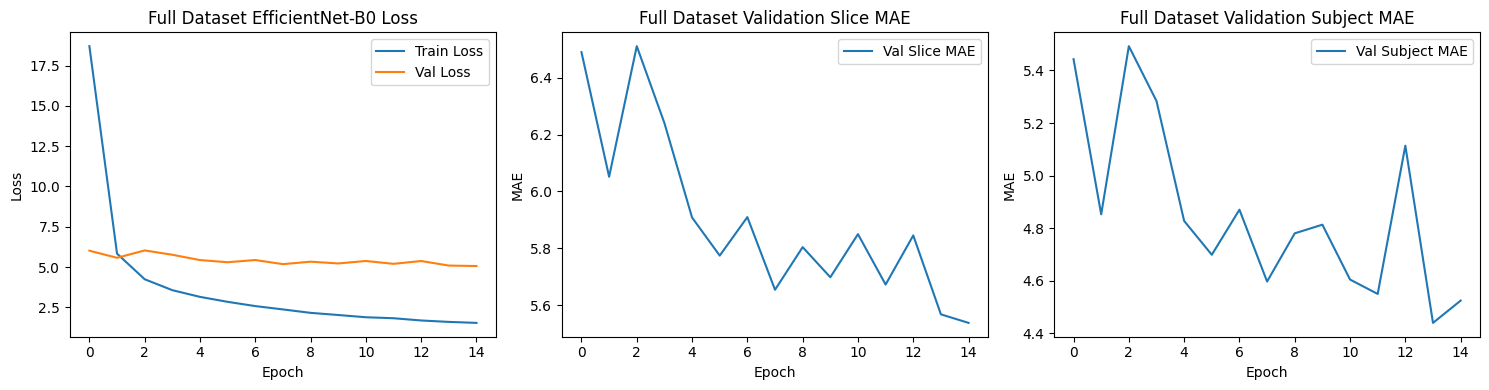

In [78]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(train_losses_full, label="Train Loss")
plt.plot(val_losses_full, label="Val Loss")
plt.title("Full Dataset EfficientNet-B0 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(val_slice_maes_full, label="Val Slice MAE")
plt.title("Full Dataset Validation Slice MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(val_subject_maes_full, label="Val Subject MAE")
plt.title("Full Dataset Validation Subject MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()

Number of predictions: 7040
Number of targets: 7040


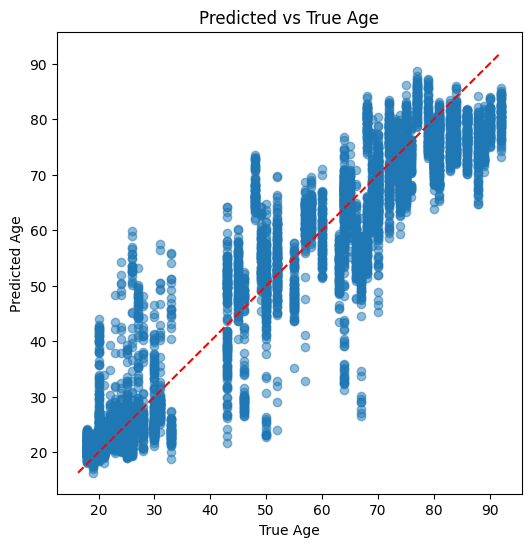

In [79]:
plot_predictions(model_full, test_loader, device)

## Final Conclusion

### What was tested

This notebook compared multiple pretrained backbones in a fast screening stage, then retrained the selected model on a larger multi-disc setup.

### What won

EfficientNet-B0 showed the best overall trade-off and was selected for scale-up.

### Main result

In the scaled stage, the workflow reached a test subject MAE of approximately **4.59 years**, validating the architecture-selection strategy.

### Why this matters

The two-step process reduces wasted compute while preserving scientific rigor: quick model ranking first, deeper training only where performance justifies it.

### Key limitations

- Early screening is run on a smaller subset, so final claims rely on the scaled stage.
- The approach is 2D slice-based and does not fully exploit 3D MRI context.
- External validation beyond OASIS remains future work.